# Stability Analysis

**Learning Goals**
- Understand what stability means in a control context
- Distinguish stable, marginally stable, and unstable systems through pendulum examples
- Use pole locations in the $s$-plane as a stability indicator
- Apply Routh's criterion to determine stability without computing poles
- Understand the role of a controller in shaping system behavior

## Relevant lecture videos

In [1]:
from IPython.display import HTML

HTML('<iframe width="560" height="315" src="https://echo360.org/media/4e01afa2-9f4e-41d1-b690-7e75d5632842/public?autoplay=false&automute=false&currentMediaId=6d9eefb3-6335-4933-bdbc-8f44933631e7&sessionId=a198a374-65a5-4251-9e01-6459db92c556" frameborder="0" allowfullscreen></iframe>')


/home/matvei/JupyterBasedControlEngineeringTextbook/venv/lib/python3.12/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [2]:
HTML('<iframe width="560" height="315" src="https://echo360.org/media/fa43af57-aac6-45ab-b892-d4884ff4c484/public?autoplay=false&automute=false&currentMediaId=4144eb93-66b3-458f-afd3-26d3a5ce2045" frameborder="0" allowfullscreen></iframe>')

In [3]:
HTML('<iframe width="560" height="315" src="https://echo360.org/media/7028af16-cbb9-45dd-bbe0-098cd83aec90/public?autoplay=false&automute=false&currentMediaId=48ec415b-b906-4762-8756-21b709d0420b" frameborder="0" allowfullscreen></iframe>')

In [4]:
HTML('<iframe width="560" height="315" src="https://echo360.org/media/e110931a-d925-499b-a7d6-47a47e793505/public?autoplay=false&automute=false&currentMediaId=bca74846-40c2-4197-9917-eba0dd275d19" frameborder="0" allowfullscreen></iframe>')

In [1]:
%pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

print("Libraries loaded.")

Libraries loaded.


In [3]:
def simulate_pendulum(theta0, omega0, c=0.5, L=1.0, t_span=20.0):
    g = 9.81
    def ode(t, y):
        theta, omega = y
        dtheta = omega
        domega = -(g / L) * np.sin(theta) - c * omega
        return [dtheta, domega]
    t_eval = np.linspace(0, t_span, 800)
    sol = solve_ivp(ode, [0, t_span], [theta0, omega0],
                    t_eval=t_eval, method='RK45', rtol=1e-8)
    return sol.t, sol.y[0], sol.y[1]

def compute_linearized_poles(case, c=0.5, L=1.0):
    g = 9.81
    if case == 'damped':
        disc = c**2 - 4 * g / L
        if disc >= 0:
            return [(-c + np.sqrt(disc)) / 2, (-c - np.sqrt(disc)) / 2]
        else:
            return [complex(-c/2, np.sqrt(-disc)/2), complex(-c/2, -np.sqrt(-disc)/2)]
    elif case == 'undamped':
        omega = np.sqrt(g / L)
        return [complex(0, omega), complex(0, -omega)]
    elif case == 'inverted':
        disc = c**2 + 4 * g / L
        return [(-c + np.sqrt(disc)) / 2, (-c - np.sqrt(disc)) / 2]

def plot_splane(ax, poles, limit=5):
    ax.axhline(0, color='k', linewidth=0.8)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set(xlabel='Re($s$)', ylabel='Im($s$)', title='$s$-Plane')
    ax.grid(alpha=0.3)
    for p in poles:
        ax.plot(p.real, p.imag, 'rx', markersize=12, markeredgewidth=3)
        ax.annotate(f'{p.real:.2f}{p.imag:+.2f}j',
                    (p.real, p.imag), xytext=(5, 5),
                    textcoords='offset points', fontsize=8)
    ax.axvspan(-limit, 0, alpha=0.06, color='g')
    ax.axvspan(0, limit, alpha=0.06, color='r')
    ax.text(-limit*0.9, limit*0.85, 'Stable', fontsize=9, color='g', fontweight='bold')
    ax.text(limit*0.05, limit*0.85, 'Unstable', fontsize=9, color='r', fontweight='bold')
    ax.axis('equal')

def routh_array(coeffs):
    n = len(coeffs) - 1
    if n < 1:
        return []
    row1 = coeffs[0::2]
    row2 = coeffs[1::2]
    max_len = max(len(row1), len(row2))
    row1 = row1 + [0] * (max_len - len(row1))
    row2 = row2 + [0] * (max_len - len(row2))
    rows = [row1, row2]
    for i in range(2, n + 1):
        prev1, prev2 = rows[i-2], rows[i-1]
        row = []
        for j in range(max_len - 1):
            if prev2[0] == 0:
                row.append(0)
            else:
                val = -(prev1[0] * prev2[j+1] - prev2[0] * prev1[j+1]) / prev2[0]
                row.append(val)
        row.append(0)
        rows.append(row)
    return rows

print("Helpers defined.")

Helpers defined.


## What is Stability?

In control engineering, **stability** describes whether a system returns to equilibrium after a disturbance.

We classify stability into three categories:
- **Stable**: the system returns to equilibrium (disturbance dies out)
- **Marginally stable**: the system oscillates indefinitely (disturbance neither grows nor decays)
- **Unstable**: the system moves away from equilibrium (disturbance grows)

The classic example to illustrate all three is the **pendulum**.

---

## Poles as a Stability Indicator

For a linear system in **state-space form**:

$$\dot{\mathbf{x}} = A\mathbf{x} + B\mathbf{u}, \qquad \mathbf{y} = C\mathbf{x} + D\mathbf{u}$$

the **system matrix $A$** captures the internal dynamics. The **poles** of the system are the **eigenvalues of $A$**, obtained as the roots of the **characteristic polynomial**:

$$\det(sI - A) = 0$$

where $I$ is the identity matrix and $\det$ is the determinant. Pole locations in the $s$-plane determine stability:

| Pole location | Stability |
|---|---|
| All poles in left half-plane ($\text{Re}(s) < 0$) | **Stable** |
| Poles on imaginary axis ($\text{Re}(s) = 0$, no repeated roots) | **Marginally stable** |
| Any pole in right half-plane ($\text{Re}(s) > 0$) | **Unstable** |

### Linearized Pendulum Dynamics

For small angles near $\theta = 0$ (down), $\sin\theta \approx \theta$, giving the linearized equation:

$$\ddot{\theta} + c\dot{\theta} + \frac{g}{L}\theta = 0$$

In state-space form with $\mathbf{x} = [\theta,\; \dot{\theta}]^T$:

$$\dot{\mathbf{x}} = \begin{bmatrix} 0 & 1 \\ -\frac{g}{L} & -c \end{bmatrix} \mathbf{x}$$

The characteristic polynomial comes from $\det(sI - A) = 0$:

$$\det\begin{bmatrix} s & -1 \\ \frac{g}{L} & s + c \end{bmatrix} = s(s + c) + \frac{g}{L} = s^2 + cs + \frac{g}{L} = 0$$

This gives poles with negative real parts when $c > 0$, meaning the system is **stable**.

For the **inverted pendulum** (linearized near $\theta = \pi$, upright), let $\phi = \theta - \pi$. Since $\sin(\phi + \pi) = -\sin\phi \approx -\phi$, the linearized equation becomes:

$$\ddot{\phi} + c\dot{\phi} - \frac{g}{L}\phi = 0$$

The system matrix and characteristic polynomial are:

$$A = \begin{bmatrix} 0 & 1 \\ \frac{g}{L} & -c \end{bmatrix}, \qquad
s^2 + cs - \frac{g}{L} = 0$$

This always has a positive real root: the system is **unstable**.

For the **undamped pendulum** ($c = 0$), poles lie on the imaginary axis $s = \pm j\sqrt{g/L}$, so the system is **marginally stable**.

---

## Worked Example: Mass-Spring-Damper

Let's determine stability **by hand** for a familiar second-order system.

### Step 1: Differential Equation

A mass-spring-damper system with $m = 1$ kg, $b = 2$ N·s/m, $k = 5$ N/m:

$$\ddot{x} + 2\dot{x} + 5x = 0$$

### Step 2: State-Space Form

Choose $\mathbf{x} = [x,\; \dot{x}]^T$. Then:

$$\dot{\mathbf{x}} = \underbrace{\begin{bmatrix} 0 & 1 \\ -5 & -2 \end{bmatrix}}_{A} \mathbf{x}$$

The system matrix is $A = \begin{bmatrix} 0 & 1 \\ -5 & -2 \end{bmatrix}$.

### Step 3: Characteristic Polynomial

$$\det(sI - A) = \det\begin{bmatrix} s & -1 \\ 5 & s + 2 \end{bmatrix}
= s(s + 2) + 5 = s^2 + 2s + 5 = 0$$

### Step 4: Find the Poles

Solve $s^2 + 2s + 5 = 0$ using the quadratic formula:

$$s = \frac{-2 \pm \sqrt{4 - 20}}{2} = \frac{-2 \pm \sqrt{-16}}{2}
= -1 \pm 2j$$

### Step 5: Stability Verdict

Both poles are at $s = -1 \pm 2j$. They have **negative real parts** ($\text{Re}(s) = -1 < 0$). Therefore the system is **stable**, and any disturbance will decay over time.

The code cell below verifies this numerically.

System matrix A:
[[ 0.  1.]
 [-5. -2.]]

Characteristic polynomial: s² + (b/m)s + (k/m) = s² + 2s + 5
Poles (eigenvalues of A): -1.0000+2.0000j, -1.0000-2.0000j
Real parts: -1.0000, -1.0000
Both real parts are negative → SYSTEM IS STABLE


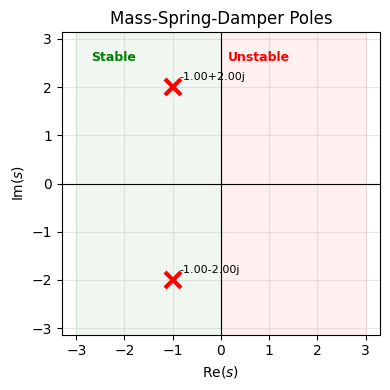

In [4]:
m, b, k = 1.0, 2.0, 5.0
A = np.array([[0, 1], [-k/m, -b/m]])
poles = np.linalg.eigvals(A)

print('System matrix A:')
print(A)
print()
print('Characteristic polynomial: s² + (b/m)s + (k/m) = s² + 2s + 5')
print(f'Poles (eigenvalues of A): {poles[0]:.4f}, {poles[1]:.4f}')
print(f'Real parts: {poles[0].real:.4f}, {poles[1].real:.4f}')
print('Both real parts are negative → SYSTEM IS STABLE')

fig, ax = plt.subplots(figsize=(4, 4))
plot_splane(ax, poles, limit=3)
ax.set_title('Mass-Spring-Damper Poles')
plt.tight_layout()
plt.show()

---

## Stability Examples

Explore the three pendulum cases below. Select a type, adjust parameters, and click **Run** to simulate the nonlinear pendulum and see the pole locations.

In [5]:
type_dd = widgets.Dropdown(
    options=['Damped pendulum (stable)',
             'Undamped pendulum (marginally stable)',
             'Inverted pendulum (unstable)'],
    value='Damped pendulum (stable)',
    description='Type:',
    style={'description_width': 'initial'}
)
damping_s = widgets.FloatSlider(min=0.0, max=2.0, step=0.1, value=0.5,
                                description='Damping $c$:',
                                style={'description_width': 'initial'})
angle_s = widgets.FloatSlider(min=1, max=45, step=1, value=15,
                              description='Disturbance (°):',
                              style={'description_width': 'initial'})
run_btn = widgets.Button(description='Run', button_style='primary')
out = widgets.Output()

def on_run(b):
    with out:
        clear_output(wait=True)
        ptype = type_dd.value
        c = damping_s.value
        theta0_deg = angle_s.value
        L = 1.0

        if 'Inverted' in ptype:
            theta0 = np.pi + np.deg2rad(theta0_deg)
            case = 'inverted'
        elif 'Undamped' in ptype:
            theta0 = np.deg2rad(theta0_deg)
            c = 0.0
            case = 'undamped'
        else:
            theta0 = np.deg2rad(theta0_deg)
            case = 'damped'

        times, theta, omega = simulate_pendulum(theta0, 0.0, c=c, L=L)
        poles = compute_linearized_poles(case, c=c, L=L)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Time response
        ax1.plot(times, np.rad2deg(theta), 'b-', lw=2)
        ax1.axhline(0, color='gray', ls='--', alpha=0.5)
        if case == 'inverted':
            ax1.axhline(180, color='gray', ls=':', alpha=0.3, label='Upright (180°)')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('$\\theta$ (deg)')
        ax1.set_title(ptype)
        ax1.grid(alpha=0.3)
        ax1.legend(fontsize=8)

        # s-plane with poles
        limit = max(5, np.ceil(max(abs(p.real) for p in poles)) + 1,
                    np.ceil(max(abs(p.imag) for p in poles)) + 1)
        plot_splane(ax2, poles, limit=limit)

        fig.tight_layout()
        plt.show()

        pole_str = ', '.join([f'{p.real:.3f} {p.imag:+.3f}j' for p in poles])
        print(f'Linearized poles: {pole_str}')

run_btn.on_click(on_run)
display(widgets.VBox([type_dd, damping_s, angle_s, run_btn, out]))

print("Select a pendulum type, adjust parameters, then click Run.")

Select a pendulum type, adjust parameters, then click Run.


**Observation.**
- The **damped pendulum** has poles in the left half-plane: the response decays to zero.
- The **undamped pendulum** has poles on the imaginary axis: it oscillates forever with constant amplitude.
- The **inverted pendulum** has one pole in the right half-plane: it falls away from upright, confirming instability.
- Pole locations in the $s$-plane directly predict the time-domain behaviour.

---

## Routh's Criterion

For systems of order higher than 2, computing poles analytically is impractical. **Routh's criterion** determines stability directly from the characteristic polynomial coefficients without solving for poles.

### Procedure

Given a characteristic polynomial:

$$a_0 s^n + a_1 s^{n-1} + a_2 s^{n-2} + \cdots + a_n = 0$$

1. **Construct the Routh array**: the first two rows come directly from coefficients; each subsequent row is computed from the two rows above it.

   $$
   \begin{aligned}
   s^n &: a_0 \quad a_2 \quad a_4 \quad a_6 \quad \cdots \\
   s^{n-1} &: a_1 \quad a_3 \quad a_5 \quad a_7 \quad \cdots \\
   s^{n-2} &: b_1 \quad b_2 \quad b_3 \quad \cdots \\
   s^{n-3} &: c_1 \quad c_2 \quad c_3 \quad \cdots \\
   &\;\vdots
   \end{aligned}
   $$

   Each entry uses the two rows above it, following the pattern:

   $$b_1 = -\frac{\det\begin{bmatrix} a_0 & a_2 \\ a_1 & a_3 \end{bmatrix}}{a_1}
   = \frac{a_1 a_2 - a_0 a_3}{a_1}, \quad
   b_2 = -\frac{\det\begin{bmatrix} a_0 & a_4 \\ a_1 & a_5 \end{bmatrix}}{a_1}
   = \frac{a_1 a_4 - a_0 a_5}{a_1}, \quad \ldots$$

   The same pattern applies for lower rows (use the two rows directly above each new entry).

2. **Count sign changes** in the first column of the array.
3. The number of sign changes equals the number of poles in the **right half-plane**.

If all entries in the first column have the same sign (all positive or all negative), the system is stable.

Try different polynomials below:

In [6]:
poly_input = widgets.Text(
    value='1, 3, 2, 6, 1, 1',
    description='Coefficients (highest first, comma-separated):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='600px')
)
routh_btn = widgets.Button(description='Analyse', button_style='primary')
routh_out = widgets.Output()

def routh_display(coeffs):
    rows = routh_array(coeffs)
    print('Characteristic polynomial: ' +
          ' + '.join([f'{c}s^{len(coeffs)-1-i}' if i < len(coeffs)-1 else f'{c}'
                     for i, c in enumerate(coeffs)]))
    print()
    print('Routh Array:')
    for i, row in enumerate(rows):
        vals = '  '.join([f'{v:10.3f}' for v in row if abs(v) > 1e-10 or True])
        print(f's^{len(rows)-1-i}:  {vals}')
    print()
    first_col = [row[0] for row in rows if abs(row[0]) > 1e-10]
    sign_changes = 0
    for i in range(1, len(first_col)):
        if first_col[i] * first_col[i-1] < 0:
            sign_changes += 1
    if sign_changes == 0 and all(v > 0 for v in first_col):
        print('Result: All poles in left half-plane → SYSTEM IS STABLE')
    elif sign_changes == 0 and all(v < 0 for v in first_col):
        print('Result: Multiply by -1: all poles in left half-plane → SYSTEM IS STABLE')
    else:
        print(f'Result: {sign_changes} sign change(s) → '
              f'{sign_changes} pole(s) in right half-plane → SYSTEM IS UNSTABLE')

def on_routh(b):
    with routh_out:
        clear_output(wait=True)
        try:
            coeffs = [float(x.strip()) for x in poly_input.value.split(',')]
            while len(coeffs) > 1 and coeffs[0] == 0:
                coeffs.pop(0)
            if len(coeffs) < 2:
                print('Please enter at least 2 coefficients.')
                return
            routh_display(coeffs)
        except ValueError:
            print('Invalid input. Use comma-separated numbers, e.g. "1, 3, 2, 6, 1, 1"')

routh_btn.on_click(on_routh)
display(widgets.VBox([poly_input, routh_btn, routh_out]))

print("Enter coefficients of a characteristic polynomial and click Analyse.")

Enter coefficients of a characteristic polynomial and click Analyse.


**Observation.** Routh's criterion is especially useful for high-order systems where computing poles by hand is difficult. It only requires the polynomial coefficients, which makes it a quick check for stability.

---

## What is a Controller?

We cannot change the internal dynamics of a physical system (the **plant**), but we can change the **input** we apply to it. This is the role of a **controller**.

In a block diagram, the controller sits **before** the plant and shapes the input signal based on:
- The **reference** (desired output)
- The **feedback** (measured output)

```
Reference → [Controller] → Input → [Plant] → Output
                  ↑                        |
                  └────── Feedback ←───────┘
```

### Control Design Steps

1. **Model** the system (identify dynamics and parameters)
2. **Add** a controller (choose a control law and gains)
3. **Evaluate** the response and stability (simulate or analyse)
4. **Iterate** steps 2–3 until the performance is satisfactory

The key insight: stability analysis tells us whether the *closed-loop* system (plant + controller) will behave as desired. A well-designed controller can stabilise an unstable plant.

---

## Summary

- **Stability** describes whether a system returns to equilibrium after a disturbance.
- **Poles** in the left half-plane → stable; on the imaginary axis → marginally stable; in the right half-plane → unstable.
- The **damped pendulum** (LHP poles), **undamped pendulum** (imaginary poles), and **inverted pendulum** (RHP pole) illustrate the three cases.
- The **system matrix $A$** and **characteristic polynomial** $\det(sI - A) = 0$ connect the state-space model to pole locations.
- The mass-spring-damper worked example shows how to derive $A$, compute $\det(sI - A)$, solve for poles, and determine stability by hand.
- **Routh's criterion** determines stability from polynomial coefficients without computing poles, which is essential for high-order systems.
- A **controller** modifies the input to a plant; we cannot change the plant itself, but we can shape its response through feedback.